# GPT-2 Word Span & Lifelong Learning Benchmarks

This notebook benchmarks a **fine-tuned local GPT-2 model** against the standard episodic recall tasks defined in the MemVal framework. We evaluate the model along four key dimensions:
1. **Presentation Duration** (Training Epochs proxy)
2. **Sequence Length** (List length variation)
3. **Multiple Sequences** (Catastrophic forgetting / interference testing)
4. **Noise Invariance** (Retrieval cue degradation)

We compare the results to the biological **DGEqProp** network baseline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from memval.encoders import SymbolicEncoder, SymbolicDecoder
from memval.models.baselines import GPT2SequenceModel

def mean_recall_rate(recall_curve):
    return float(np.mean(recall_curve[1:]))

def memory_span(recall_curve, threshold=0.75):
    span = 0
    for r in recall_curve[1:]:
        if r >= threshold:
            span += 1
        else:
            break
    return span

def measure_recall_threshold(network, words, encoder, decoder, context_vec=None,
                              n_trials=30, noise_scale=0.05):
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.reset_context()
        for i in range(len(words) - 1):
            network.current_t = i
            noisy_evt = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            raw_pred = network.predict_next(noisy_evt, current_context=context)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
    return success_counts / n_trials

def measure_recall_autoregressive(network, words, encoder, decoder, context_vec=None,
                                   n_trials=30, noise_scale=0.05):
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.reset_context()
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        for i in range(len(words) - 1):
            raw_pred = network.predict_next(current_evt, current_context=context)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
            current_evt = network.decode_prediction(raw_pred)
    return success_counts / n_trials

def recall_fidelity(network, words, encoder, context_vec=None, n_trials=30, noise_scale=0.05):
    gt_embs = encoder.encode(words)
    total_sim, count = 0.0, 0
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.reset_context()
        for i in range(len(words) - 1):
            network.current_t = i
            noisy = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            pred = network.predict_next(noisy, current_context=context)
            sim = float(pred @ gt_embs[i + 1]) / (np.linalg.norm(pred) * np.linalg.norm(gt_embs[i + 1]) + 1e-8)
            total_sim += sim
            count += 1
    return total_sim / count

## 1. Presentation Duration Benchmark

This tests how training duration (epochs) scales recall performance. We fine-tune GPT-2 for 100, 200, and 300 epochs on a 7-word fruit list.

Training GPT-2 with presentation duration = 1 (Epochs = 10)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Training GPT-2 with presentation duration = 2 (Epochs = 20)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Training GPT-2 with presentation duration = 3 (Epochs = 30)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


--- Metric Summary Table: Presentation Duration ---
---------------------------------------------------------------------------
Duration (Epochs)         | MRR        | Span (θ=0.75)   | Recall Fidelity
---------------------------------------------------------------------------
1 (10)                    | 1.000      | 6               | 1.000          
2 (20)                    | 1.000      | 6               | 1.000          
3 (30)                    | 1.000      | 6               | 1.000          
---------------------------------------------------------------------------



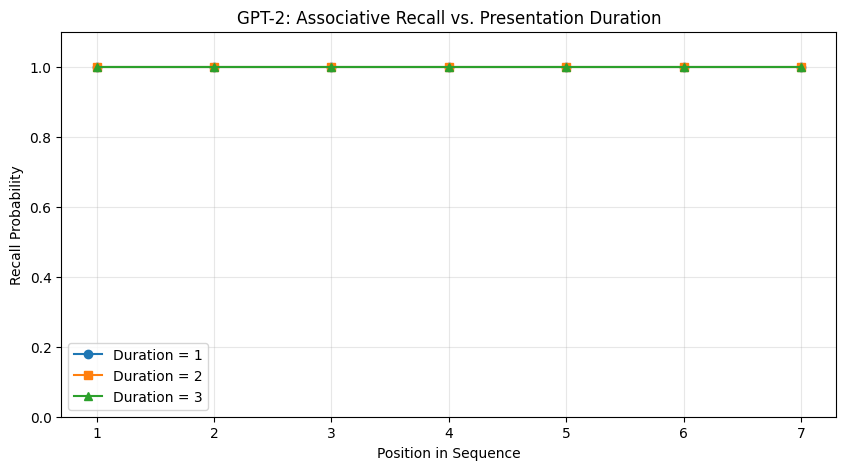

In [9]:
vocab = {
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'peach': 'fruit', 'plum': 'fruit', 'cherry': 'fruit', 'kiwi': 'fruit', 'mango': 'fruit',
    'lemon': 'fruit', 'lime': 'fruit'
}
encoder = SymbolicEncoder(vocab, embedding_dim=100, category_variance=0.2, seed=42)
decoder = SymbolicDecoder(encoder)
word_list = ['apple', 'banana', 'orange', 'grape', 'pear', 'peach', 'plum']

durations = [1, 2, 3]
base_epochs = 10
n_trials = 30

results_mrr = {}
results_span = {}
results_fidelity = {}
curves_assoc = {}

for D in durations:
    n_epochs = base_epochs * D
    print(f"Training GPT-2 with presentation duration = {D} (Epochs = {n_epochs})...")
    
    net = GPT2SequenceModel(encoder=encoder, n_epochs=n_epochs, device="cpu")
    enc_words = encoder.encode(word_list)
    context_seq = np.tile(np.array([1.0]), (len(word_list), 1))
    net.fit_sequence(enc_words, context_data=context_seq)
    
    res_theta = measure_recall_threshold(net, word_list, encoder, decoder, n_trials=n_trials)
    curves_assoc[D] = res_theta
    results_mrr[D] = mean_recall_rate(res_theta)
    results_span[D] = memory_span(res_theta)
    results_fidelity[D] = recall_fidelity(net, word_list, encoder, n_trials=n_trials)

print("\n--- Metric Summary Table: Presentation Duration ---")
print("-" * 75)
print(f"{'Duration (Epochs)':<25} | {'MRR':<10} | {'Span (θ=0.75)':<15} | {'Recall Fidelity':<15}")
print("-" * 75)
for D in durations:
    n_epochs = base_epochs * D
    label = f"{D} ({n_epochs})"
    print(f"{label:<25} | {results_mrr[D]:<10.3f} | {results_span[D]:<15} | {results_fidelity[D]:<15.3f}")
print("-" * 75 + "\n")

# Plot recall curves
plt.figure(figsize=(10, 5))
markers = ['o', 's', '^']
for i, D in enumerate(durations):
    plt.plot(range(1, len(word_list)+1), curves_assoc[D], marker=markers[i], label=f'Duration = {D}')
plt.title("GPT-2: Associative Recall vs. Presentation Duration")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Probability")
plt.xticks(range(1, len(word_list)+1))
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2. Sequence Length Benchmark

This tests working memory capacity. We vary sequence lengths from 5 to 10 words, trained for 200 epochs.

Training GPT-2 sequence of length 5...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Training GPT-2 sequence of length 7...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Training GPT-2 sequence of length 10...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Training GPT-2 sequence of length 15...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


--- Metric Summary Table: Sequence Length ---
---------------------------------------------------------------------------
Sequence Length           | MRR        | Span (θ=0.75)   | Recall Fidelity
---------------------------------------------------------------------------
5                         | 1.000      | 4               | 1.000          
7                         | 1.000      | 6               | 1.000          
10                        | 0.889      | 7               | 0.925          
15                        | 0.786      | 7               | 0.843          
---------------------------------------------------------------------------



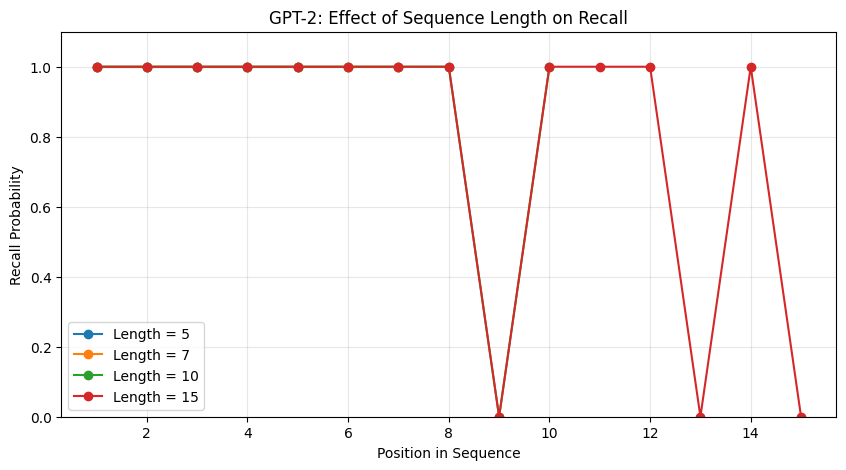

In [11]:
extended_vocab = {
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'peach': 'fruit', 'plum': 'fruit', 'cherry': 'fruit', 'kiwi': 'fruit', 'mango': 'fruit',
    'lemon': 'fruit', 'lime': 'fruit', 'apricot': 'fruit', 'fig': 'fruit', 'melon': 'fruit',
    'papaya': 'fruit', 'coconut': 'fruit'
}
ext_encoder = SymbolicEncoder(extended_vocab, embedding_dim=100, category_variance=0.2, seed=42)
ext_decoder = SymbolicDecoder(ext_encoder)
full_word_list = list(extended_vocab.keys())

seq_lengths = [5, 7, 10, 15]
n_epochs_len = 20
results_mrr_len = {}
results_span_len = {}
results_fidelity_len = {}
curves_len = {}

for length in seq_lengths:
    print(f"Training GPT-2 sequence of length {length}...")
    current_words = full_word_list[:length]
    enc_words = ext_encoder.encode(current_words)
    context_seq = np.tile(np.array([1.0]), (len(current_words), 1))
    
    net = GPT2SequenceModel(encoder=ext_encoder, n_epochs=n_epochs_len, device="cpu")
    net.fit_sequence(enc_words, context_data=context_seq)
    
    probs_theta = measure_recall_threshold(net, current_words, ext_encoder, ext_decoder, n_trials=n_trials)
    curves_len[length] = probs_theta
    results_mrr_len[length] = mean_recall_rate(probs_theta)
    results_span_len[length] = memory_span(probs_theta)
    results_fidelity_len[length] = recall_fidelity(net, current_words, ext_encoder, n_trials=n_trials)

print("\n--- Metric Summary Table: Sequence Length ---")
print("-" * 75)
print(f"{'Sequence Length':<25} | {'MRR':<10} | {'Span (θ=0.75)':<15} | {'Recall Fidelity':<15}")
print("-" * 75)
for length in seq_lengths:
    print(f"{length:<25} | {results_mrr_len[length]:<10.3f} | {results_span_len[length]:<15} | {results_fidelity_len[length]:<15.3f}")
print("-" * 75 + "\n")

plt.figure(figsize=(10, 5))
for length in seq_lengths:
    plt.plot(range(1, length+1), curves_len[length], marker='o', label=f'Length = {length}')
plt.title("GPT-2: Effect of Sequence Length on Recall")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Probability")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. Multiple Sequences Benchmark (Catastrophic Forgetting)

This benchmark tests weights retention under sequential training of distinct categories (Fruits, Animals, Cars).

In [4]:
vocab_multi = {
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'dog': 'animal', 'cat': 'animal', 'horse': 'animal', 'cow': 'animal', 'sheep': 'animal',
    'ford': 'car', 'chevy': 'car', 'dodge': 'car', 'toyota': 'car', 'honda': 'car'
}
encoder_multi = SymbolicEncoder(vocab_multi, embedding_dim=100, category_variance=0.2, seed=42)
decoder_multi = SymbolicDecoder(encoder_multi)

lists = {
    'fruits': ['apple', 'banana', 'orange', 'grape', 'pear'],
    'animals': ['dog', 'cat', 'horse', 'cow', 'sheep'],
    'cars': ['ford', 'chevy', 'dodge', 'toyota', 'honda']
}
rng = np.random.default_rng(42)
context_map = {
    'fruits':  rng.integers(0, 2, size=32).astype(float),
    'animals': rng.integers(0, 2, size=32).astype(float),
    'cars':    rng.integers(0, 2, size=32).astype(float),
}

net_multi = GPT2SequenceModel(encoder=encoder_multi, n_epochs=300, device="cpu")
stages_data = []

for idx, (cat, words) in enumerate(lists.items()):
    enc_words = encoder_multi.encode(words)
    context_seq = np.tile(context_map[cat], (len(words), 1))
    
    print(f"Stage {idx+1}: Training GPT-2 ONLY on {cat}...")
    net_multi.fit_sequences([(enc_words, context_seq)])
    
    stage_metrics = {}
    for c_cat in lists.keys():
        c_words = lists[c_cat]
        c_context = context_map[c_cat]
        
        curve_assoc = measure_recall_threshold(net_multi, c_words, encoder_multi, decoder_multi, c_context, n_trials=n_trials)
        curve_auto = measure_recall_autoregressive(net_multi, c_words, encoder_multi, decoder_multi, c_context, n_trials=n_trials)
        
        mrr = mean_recall_rate(curve_assoc)
        span = memory_span(curve_auto, threshold=0.75)
        fid = recall_fidelity(net_multi, c_words, encoder_multi, context_vec=c_context, n_trials=n_trials)
        
        stage_metrics[c_cat] = {'mrr': mrr, 'span': span, 'fidelity': fid}
    stages_data.append(stage_metrics)
    
    print("=" * 65)
    print(f"  Stage {idx+1} Primary Metrics (after training on: {cat})")
    print("-" * 65)
    print(f"  {'Category':<15} | {'MRR (Assoc)':<12} | {'Word Span':<12} | {'Recall Fidelity':<15}")
    print("-" * 65)
    for c_cat in lists.keys():
        metrics = stage_metrics[c_cat]
        print(f"  {c_cat:<15} | {metrics['mrr']:<12.3f} | {metrics['span']:<12} | {metrics['fidelity']:<15.3f}")
    print("=" * 65)
    print()


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Stage 1: Training GPT-2 ONLY on fruits...
  Stage 1 Primary Metrics (after training on: fruits)
-----------------------------------------------------------------
  Category        | MRR (Assoc)  | Word Span    | Recall Fidelity
-----------------------------------------------------------------
  fruits          | 1.000        | 4            | 1.000          
  animals         | 0.000        | 0            | -0.094         
  cars            | 0.000        | 0            | -0.026         

Stage 2: Training GPT-2 ONLY on animals...
  Stage 2 Primary Metrics (after training on: animals)
-----------------------------------------------------------------
  Category        | MRR (Assoc)  | Word Span    | Recall Fidelity
-----------------------------------------------------------------
  fruits          | 0.000        | 0            | -0.053         
  animals         | 1.000        | 4            | 1.000          
  cars            | 0.000        | 0            | 0.052          

Stage 3: Tra

## 4. Noise Invariance Benchmark

This benchmark sweeps different noise levels added to the cue vector at recall time, measuring how gracefully recall decays.

Training baseline network for Noise Invariance task...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Evaluating noise scale σ = 0.05...
Evaluating noise scale σ = 0.2...
Evaluating noise scale σ = 0.5...
Evaluating noise scale σ = 0.8...
Evaluating noise scale σ = 1.0...

--- Metric Summary Table: Noise Invariance ---
---------------------------------------------------------------------------
Noise Scale (σ)           | MRR        | Span (θ=0.75)   | Recall Fidelity
---------------------------------------------------------------------------
0.05                      | 1.000      | 6               | 1.000          
0.20                      | 0.989      | 6               | 0.995          
0.50                      | 0.628      | 0               | 0.656          
0.80                      | 0.461      | 0               | 0.520          
1.00                      | 0.378      | 0               | 0.513          
---------------------------------------------------------------------------



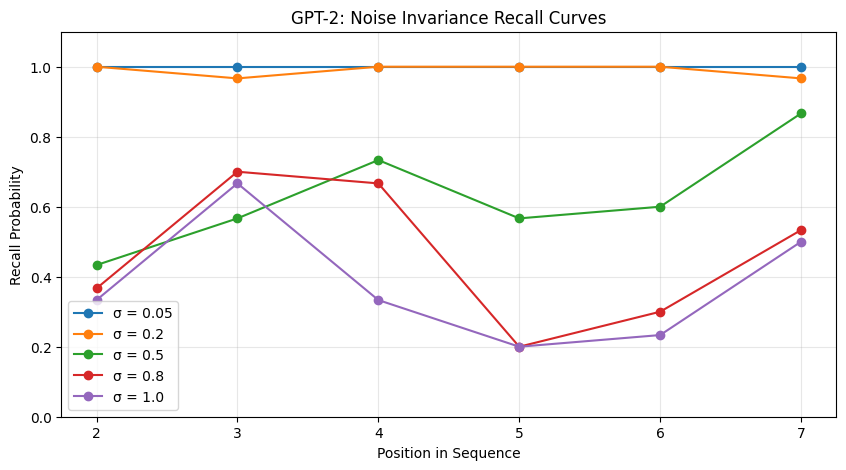

In [8]:
noise_scales = [0.05, 0.2, 0.5, 0.8, 1.0]
results_mrr_n = {}
results_span_n = {}
results_fidelity_n = {}
curves_noise = {}

print("Training baseline network for Noise Invariance task...")
net_n = GPT2SequenceModel(encoder=encoder, n_epochs=200, device="cpu")
enc_words_n = encoder.encode(word_list)
context_seq_n = np.tile(np.array([1.0]), (len(word_list), 1))
net_n.fit_sequence(enc_words_n, context_data=context_seq_n)

for sigma in noise_scales:
    print(f"Evaluating noise scale σ = {sigma}...")
    res_theta = measure_recall_threshold(net_n, word_list, encoder, decoder, noise_scale=sigma)
    curves_noise[sigma] = res_theta
    results_mrr_n[sigma] = mean_recall_rate(res_theta)
    results_span_n[sigma] = memory_span(res_theta)
    results_fidelity_n[sigma] = recall_fidelity(net_n, word_list, encoder, noise_scale=sigma)

print("\n--- Metric Summary Table: Noise Invariance ---")
print("-" * 75)
print(f"{'Noise Scale (σ)':<25} | {'MRR':<10} | {'Span (θ=0.75)':<15} | {'Recall Fidelity':<15}")
print("-" * 75)
for sigma in noise_scales:
    print(f"{sigma:<25.2f} | {results_mrr_n[sigma]:<10.3f} | {results_span_n[sigma]:<15} | {results_fidelity_n[sigma]:<15.3f}")
print("-" * 75 + "\n")

plt.figure(figsize=(10, 5))
for sigma in noise_scales:
    plt.plot(range(2, len(word_list)+1), curves_noise[sigma][1:], marker='o', label=f'σ = {sigma}')
plt.title("GPT-2: Noise Invariance Recall Curves")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Probability")
plt.xticks(range(2, len(word_list)+1))
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()